# 02 · Results: can you make money from it?

Notebook 01 showed that the total S of all YES prices keeps getting pulled back towards its average. The strategy from the blueprint
tries to profit from that:

1. Track the average **μ** and the typical size of moves **σ** of S over its last **N** changes.
2. Compute the **z-score** $z = (S - \mu) / \sigma$: how many "typical moves" S is away from its average.
3. If **z > +z_entry**, S looks too *expensive*: **sell the basket**. On Polymarket you can't sell what you don't own, so we instead
   **buy a "NO" share of every outcome**. NO pays $1 when that outcome does *not* happen, so a full set of NOs pays exactly (n − 1) dollars.
4. If **z < −z_entry**, S looks too *cheap*: **buy one YES of every outcome**. The full set pays exactly $1.
5. When S comes back near its average (**|z| < z_exit**), close the position.

Everything is simulated with real trading frictions: you buy at the ask and sell at the bid, larger orders eat into deeper (worse) prices,
Polymarket's taker fee is charged, and orders arrive with a small delay. No real orders are ever placed.

In [1]:
import sys, json, math, warnings, dataclasses
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import logging; logging.getLogger("src").setLevel(logging.ERROR)  # the live recorder may be mid-write
import numpy as np, pandas as pd
from IPython.display import Markdown, display
from src import plotting as P, stats_tools as st, research as R, RESULTS_ROOT
from src.config import load_markets, basket_fee_per_unit
from src.data_io import load_real_prices, load_real_books, DataUnavailable
from src.pipeline import RunConfig, run_backtest, fast_grid
from src.arb_engine import ZConfig, SignalConfig
from src.execution_sim import ExecConfig
pd.set_option("display.float_format", "{:.4f}".format)
cfg = load_markets()
BASKET = "fed-oct-2026"

def usd(x):
    return f"{'+' if x >= 0 else '−'}${abs(x):,.0f}"

## 1. Choosing the settings fairly (train / validation / test)

If we tried lots of settings and reported the best one on the same data, the result would look far better than reality (*overfitting*).
So the 30 days are split by time:

* **training (first 60%)**: measure how fast S reverts;
* **validation (next 20%)**: try a small grid of settings (window N, entry and exit thresholds) and pick a good, *stable* one;
* **test (last 20%)**: run the chosen settings **once**. Only these results count.

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-09-02T03:01:00 | 2026-10-02T02:59:00 | 720.0 | 43,189 | 1 |

> Execution books are MODELLED: per-leg spread 50-bps-decrease=1 tick(s), 25-bps-decrease=1 tick(s), no-change=1 tick(s), 25-bps-increase=1 tick(s), 50-bps-increase=1 tick(s) (medians of the recorded live books).

Tried **72** settings on the validation days. Chosen: window **N = 87** changes of S, enter at **|z| > 1.5**, exit at **|z| < 0.5**. Best validation profit *ignoring costs*: +0.187 $ per basket; best *after costs*: +0.000 $ per basket.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


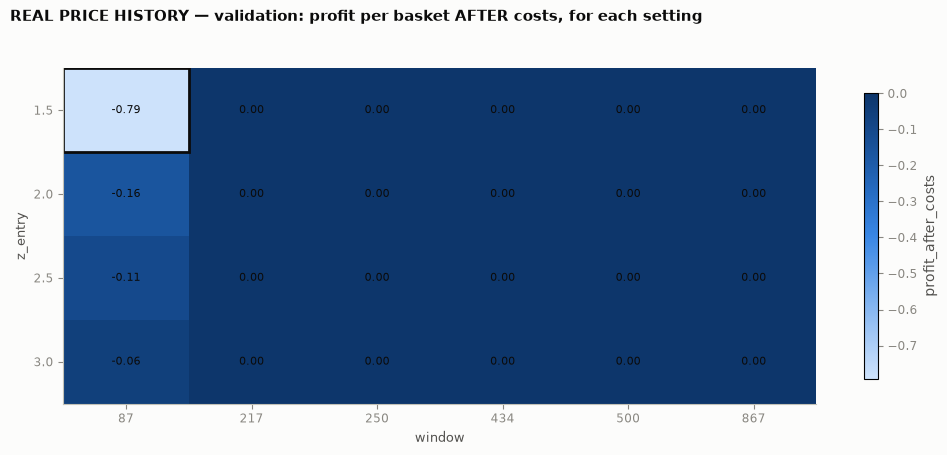

In [2]:
ds = load_real_prices(BASKET, cfg=cfg)
display(Markdown(ds.info.banner_markdown()))
DK = ds.info.label
prices, _ = R.price_panel(BASKET, cfg)
S = prices.sum(axis=1)
book = R.book_sums(BASKET, cfg)
spread = float((book[0]["s_ask"] - book[0]["s_bid"]).median()) if book is not None else 0.005 * ds.basket.n_legs
fee = basket_fee_per_unit(ds.basket.fees, prices.mean().to_numpy())
sums = pd.DataFrame({"t_ns": S.index.as_unit("ns").asi8, "s_mid": S.to_numpy(), "s_bid": S.to_numpy() - spread / 2,
                     "s_ask": S.to_numpy() + spread / 2, "valid": True}, index=S.index)
train, val, test = st.walk_forward_splits(len(sums), 0.6, 0.2, embargo=6 * 60)
tr = sums.iloc[train]
changes_per_min = float((tr["s_mid"].diff().fillna(1) != 0).mean())
half_life_changes = st.ar1_fit(tr["s_mid"], 60.0)["half_life_s"] / 60 * changes_per_min
windows = sorted({max(int(round(k * half_life_changes)), 5) for k in (10, 25, 50, 100)} | {250, 500})
grid_kw = dict(windows=windows, z_entries=[1.5, 2.0, 2.5, 3.0], z_exits=[0.0, 0.2, 0.5])
g_mid = fast_grid(sums.iloc[val], fee, ds.basket.n_legs, cost_mode="mid", **grid_kw)
g_cost = fast_grid(sums.iloc[val], fee, ds.basket.n_legs, cost_mode="taker", **grid_kw)
grid = g_mid[["window", "z_entry", "z_exit", "n_trades"]].assign(profit_ignoring_costs=g_mid["pnl_per_unit"],
                                                                  profit_after_costs=g_cost["pnl_per_unit"].to_numpy())
pick = st.plateau_select(grid.assign(score=grid["profit_ignoring_costs"]), "score", ["window", "z_entry", "z_exit"])["params"]
sel = {"window": int(pick["window"]), "z_entry": float(pick["z_entry"]), "z_exit": float(pick["z_exit"])}
test_start_ns = int(sums.index[test][0].value)
display(Markdown(f"Tried **{len(grid)}** settings on the validation days. Chosen: window **N = {sel['window']}** changes of S, "
                 f"enter at **|z| > {sel['z_entry']}**, exit at **|z| < {sel['z_exit']}**. "
                 f"Best validation profit *ignoring costs*: {grid['profit_ignoring_costs'].max():+.3f} $ per basket; "
                 f"best *after costs*: {grid['profit_after_costs'].max():+.3f} $ per basket."))
P.show(P.plot_grid_heatmap(grid[grid.z_exit == sel["z_exit"]], x="window", y="z_entry", value="profit_after_costs", data_kind=DK,
                           title="validation: profit per basket AFTER costs, for each setting", selected=sel), "02_grid_after_costs")

## 2. The test: two strategies

* **A · blueprint**: trade every time |z| crosses the threshold, exactly as specified.
* **B · cost-aware**: same signal, but only enter if the expected profit is still positive **after** paying the spread and fees
  (otherwise skip the signal).

In [3]:
base = ExecConfig.from_defaults(cfg.defaults)

def run(data=ds, **ex):
    rc = RunConfig(z=ZConfig(window=sel["window"]), signal=SignalConfig(z_entry=sel["z_entry"], z_exit=sel["z_exit"]),
                   exec=dataclasses.replace(base, **ex), trade_start_ns=test_start_ns)
    return run_backtest(data, rc)

A = run()
B = run(gate="edge", exit_policy="hybrid")
fee_free_basket = dataclasses.replace(ds.basket, legs=tuple(dataclasses.replace(l, fee=dataclasses.replace(l.fee, rate=0.0))
                                                             for l in ds.basket.legs))
A0 = run(data=dataclasses.replace(ds, basket=fee_free_basket))

def summary(name, r):
    t, s = r.trades, r.summary
    n = len(t)
    return {"strategy": name, "trades": n, "profit/loss": r.attribution["net"], "return": s.get("total_return", 0.0),
            "win rate": float((t["pnl_net"] > 0).mean()) if n else float("nan"),
            "worst drop (max drawdown)": s.get("max_dd", 0.0), "Sharpe ratio": s.get("sharpe_display", "n/a")}

table = pd.DataFrame([summary("A · blueprint", A), summary("B · cost-aware", B),
                      summary("A · blueprint if there were NO fees", A0)]).set_index("strategy")
display(table)

,trades,profit/loss,return,win rate,worst drop (max drawdown),Sharpe ratio
strategy,,,,,,
A · blueprint,18,-1187.8183,-0.1188,0.0000,-0.1265,-8.54
B · cost-aware,0,0.0000,0.0000,NaN,0.0000,n/a
A · blueprint if there were NO fees,18,-27.7069,-0.0028,0.1667,-0.0123,-1.65


## 3. The main chart

**Top:** the total S (blue) with its rolling average and the "± z_entry" band. ▲ = bought the YES set, ▼ = bought the NO set, × = exit.
The grey band shows what you could actually trade at (sell at the bids, buy at the asks).
**Bottom:** the simulated account balance, starting from $10,000.

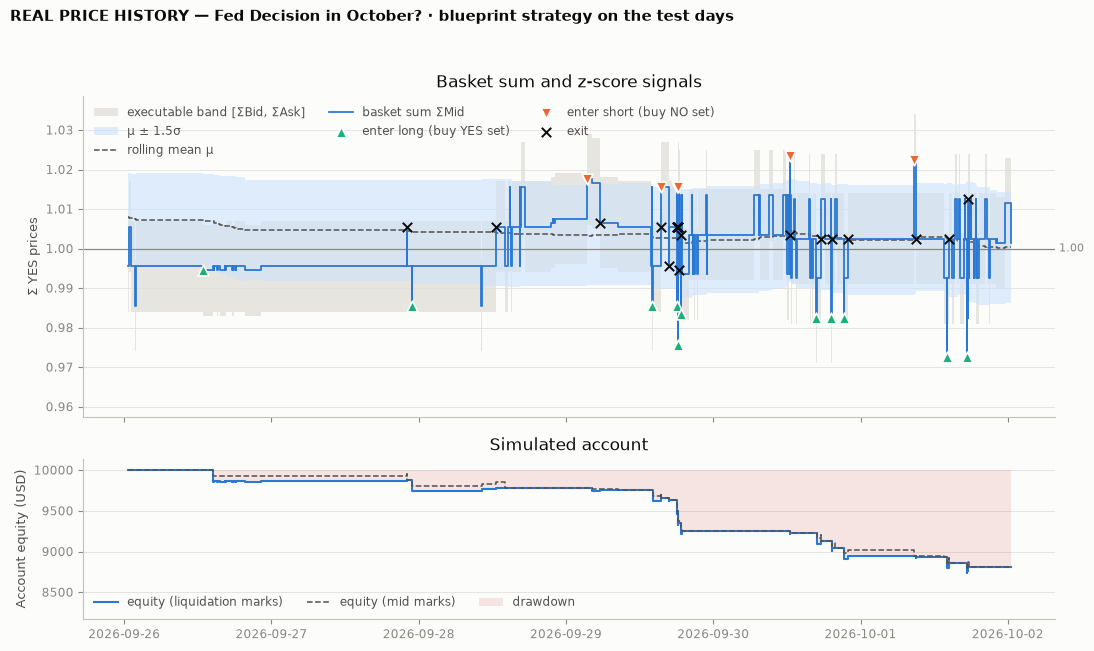

In [4]:
t0 = pd.Timestamp(test_start_ns, tz="UTC") - pd.Timedelta(hours=12)
ser, eq = A.series[A.series.index >= t0], A.equity[A.equity.index >= t0]
P.show(P.plot_basket_signal_equity(ser, A.trades, eq, z_entry=sel["z_entry"], data_kind=DK,
                                   title=f"{ds.basket.title} · blueprint strategy on the test days"), "basket_signal_equity")

## 4. Where did the money go?

Every trade's profit can be split exactly into: what the **signal** earned (price moved the right way, measured at midpoints), minus what
was lost to the **spread** (buying above and selling below the midpoint), minus **fees**.

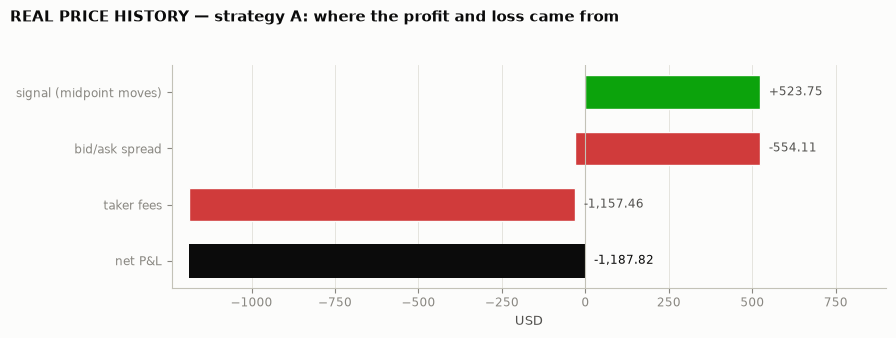

In [5]:
a = A.attribution
P.show(P.plot_attribution({"signal (midpoint moves)": a["gross_mid"], "bid/ask spread": a["half_spread"] + a["depth_slippage"],
                           "taker fees": -a["fees"], "other": a["latency_drift"] + a["payoff_adjustment"] - a["gas"] - a["legging_cost"],
                           "net": a["net"]}, data_kind=DK, title="strategy A: where the profit and loss came from"), "attribution")

In [6]:
try:
    live = load_real_books(BASKET, cfg=cfg)
    arb = run_backtest(live, RunConfig(strategy="arb", exec=dataclasses.replace(base, gate="arb_only", exit_policy="hold")))
    bs = R.band_stats(R.book_sums(BASKET, cfg)[0], ds.basket)
    live_row = {"hours": live.info.hours, "arb trades": len(arb.trades), "min S_ask": bs["min S_ask"], "max S_bid": bs["max S_bid"],
                "median n-leg spread": bs["median spread_sum"]}
    display(Markdown(live.info.banner_markdown()))
    display(Markdown(f"Cross-check on **{live_row['hours']:.1f} hours of recorded live order books**: the cheapest a full YES set ever cost was "
                     f"${live_row['min S_ask']:.3f} and a full set sold for at most ${live_row['max S_bid']:.3f}, so no risk-free trade existed "
                     f"({live_row['arb trades']} found)."))
except DataUnavailable:
    live_row = None

**DATA: REAL Polymarket order books** recorded live from the CLOB market WebSocket.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-10-01T22:30:10 | 2026-10-02T06:55:46 | 6.4 | 3,130 | 6 |

> Only 6.4 h of live books so far (recording continues in ≤2 h chunks); treat backtest statistics on this sample as anecdotal.

Cross-check on **6.4 hours of recorded live order books**: the cheapest a full YES set ever cost was $1.013 and a full set sold for at most $0.990, so no risk-free trade existed (0 found).

In [7]:
display(Markdown("### Conclusion\n" + "\n".join([
    f"* **The signal works:** strategy A's trades moved the right way, worth **{usd(a['gross_mid'])}** at midpoint prices.",
    f"* **Costs are bigger than the signal:** the bid/ask spread cost **{usd(a['half_spread'] + a['depth_slippage'])}** and fees "
    f"**{usd(-a['fees'])}**, so A ended at **{usd(a['net'])}** ({A.summary.get('total_return', 0):+.1%}). "
    f"Even with zero fees it would end at {usd(A0.attribution['net'])}.",
    f"* **Being cost-aware avoids the loss:** strategy B made {len(B.trades)} trades, because no signal was big enough to pay for the costs.",
    "* **Lesson:** the prices really do add up to about $1 and drift back, but the moves (a cent or two) are smaller than the cost of trading "
    "every outcome. Making money would need cheaper execution, e.g. placing limit orders instead of paying the spread.",
])))

### Conclusion
* **The signal works:** strategy A's trades moved the right way, worth **+$524** at midpoint prices.
* **Costs are bigger than the signal:** the bid/ask spread cost **−$554** and fees **−$1,157**, so A ended at **−$1,188** (-11.9%). Even with zero fees it would end at −$28.
* **Being cost-aware avoids the loss:** strategy B made 0 trades, because no signal was big enough to pay for the costs.
* **Lesson:** the prices really do add up to about $1 and drift back, but the moves (a cent or two) are smaller than the cost of trading every outcome. Making money would need cheaper execution, e.g. placing limit orders instead of paying the spread.

In [8]:
def clean(v):
    if isinstance(v, (np.floating, float)):
        return None if not math.isfinite(float(v)) else float(v)
    if isinstance(v, np.integer):
        return int(v)
    return v if isinstance(v, (int, str, bool, type(None))) else str(v)

test_window = [str(sums.index[test][0]), str(sums.index[test][-1])]
(RESULTS_ROOT / "selected_params.json").write_text(json.dumps({**sel, "basket": BASKET, "n_configs": len(grid),
                                                               "test": test_window, "test_start_ns": test_start_ns,
                                                               "spread_sum": spread, "fee_per_unit": fee}, indent=1))
(RESULTS_ROOT / "metrics.json").write_text(json.dumps({
    "basket": BASKET, "data_kind": DK, "test": test_window, "params": sel,
    "strategies": {i: {k: clean(v) for k, v in r.items()} for i, r in table.iterrows()},
    "attribution_A": {k: clean(v) for k, v in a.items()}, "fee_free_net_A": clean(A0.attribution["net"]),
    "headline": {k: clean(v) for k, v in A.summary.items() if not isinstance(v, (dict, list))},
    "live_books": {k: clean(v) for k, v in live_row.items()} if live_row else None}, indent=1))
A.trades.drop(columns=[c for c in A.trades.columns if c.startswith("attr_")], errors="ignore").to_csv(RESULTS_ROOT / "trades.csv", index=False)
R.save_dataset_info("02", [ds.info] + ([live.info] if live_row else []))
print("saved results/metrics.json, results/trades.csv, results/selected_params.json")

saved results/metrics.json, results/trades.csv, results/selected_params.json


### Caveats
* The test covers one event, six days and fewer than 30 trades, so treat the numbers as an example, not proof.
* For the 30-day test the bid/ask prices are *modelled* around the real midpoints (using the spread measured in the recorded live books).
* Simulation only: real trading would also face the risk of one outcome filling and another not ("legging").